<a href="https://colab.research.google.com/github/nagasailakshmiMaddala/PRODIGY_DS_03/blob/main/PRODIGY_DS_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Load the dataset
df = pd.read_csv('/content/bank_marketing_dataset/bank-full.csv', sep=';')

# Display the first 5 rows and basic info of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [15]:
# Convert categorical features into numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'])

# Convert the target variable 'y' to numerical (0 for 'no', 1 for 'yes')
df_encoded['y'] = df_encoded['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Display the first 5 rows of the encoded DataFrame and its info to verify changes
print("First 5 rows of the encoded dataset:")
display(df_encoded.head())
print("\nEncoded DataFrame Info:")
df_encoded.info()

First 5 rows of the encoded dataset:


,age,balance,day,duration,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,True,False,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,True,False,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,False,...,False,False,True,False,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,False,True,...,False,False,True,False,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,True,False,False,False,False,False,False,True



Encoded DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   balance              45211 non-null  int64
 2   day                  45211 non-null  int64
 3   duration             45211 non-null  int64
 4   campaign             45211 non-null  int64
 5   pdays                45211 non-null  int64
 6   previous             45211 non-null  int64
 7   y                    45211 non-null  int64
 8   job_admin.           45211 non-null  bool 
 9   job_blue-collar      45211 non-null  bool 
 10  job_entrepreneur     45211 non-null  bool 
 11  job_housemaid        45211 non-null  bool 
 12  job_management       45211 non-null  bool 
 13  job_retired          45211 non-null  bool 
 14  job_self-employed    45211 non-null  bool 
 15  job_services         45211 non-null  bool 
 1

In [16]:
# Separate features (X) and target variable (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split the data into training and testing sets
# Using a 70/30 split, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (31647, 51)
Testing set shape: (13564, 51)


In [17]:
# Initialize the Decision Tree Classifier
# Setting max_depth to a reasonable number to prevent overfitting and for better visualization
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train the classifier on the training data
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


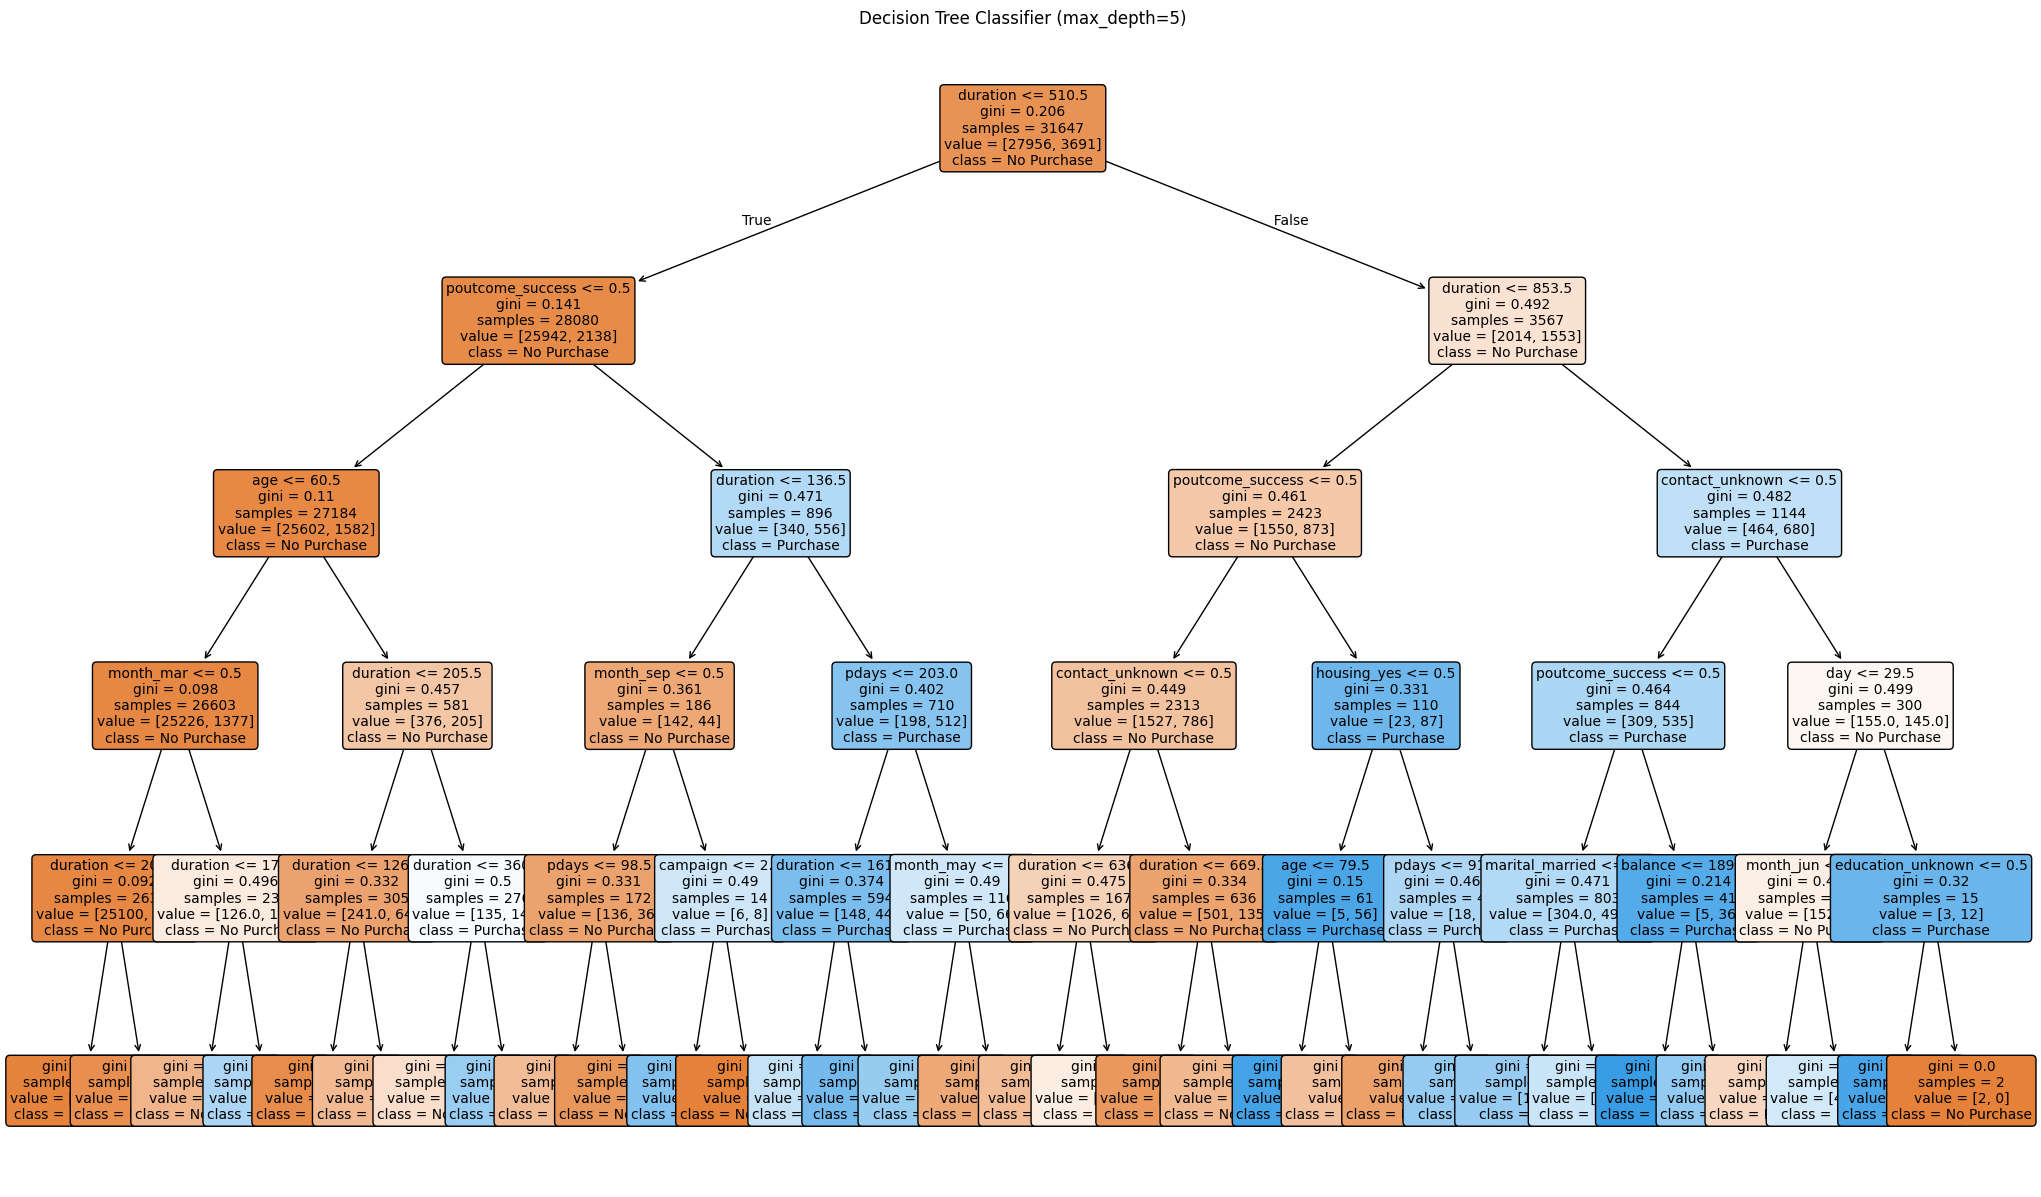

In [18]:
# Visualize the decision tree
plt.figure(figsize=(25,15))
plot_tree(dt_classifier,
          feature_names=X.columns.tolist(),
          class_names=['No Purchase', 'Purchase'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Classifier (max_depth=5)")
plt.show()


--- Model Evaluation ---
Accuracy: 0.9009

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.92      0.97      0.95     11966
    Purchase       0.65      0.35      0.45      1598

    accuracy                           0.90     13564
   macro avg       0.78      0.66      0.70     13564
weighted avg       0.89      0.90      0.89     13564



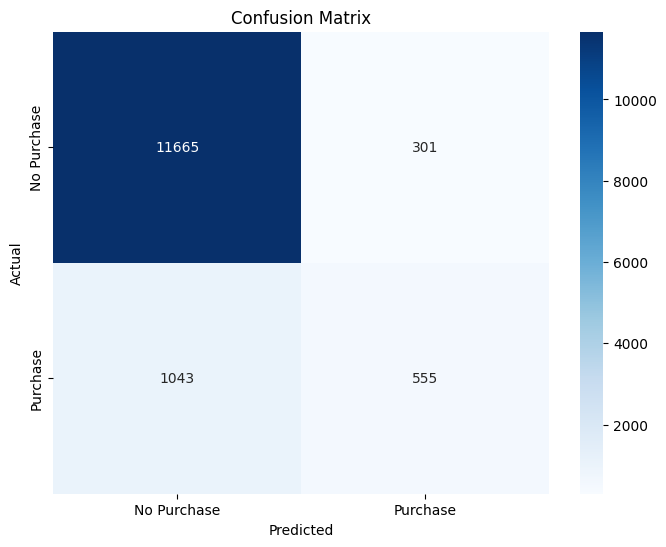

In [19]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()